In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 데이터셋을 라이브러리에서 가저올예정 파일에서도 봄

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist   #mnist 손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩(pd.get dummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
import matplotlib.pyplot as plt #시각화

In [8]:
data=np.loadtxt('data/mnist_train_small.csv',delimiter=',',skiprows=1)
data.shape

(100, 785)

In [33]:
print('타겟변수:', data[0,0])
image=data[45,1:].reshape(28,28)
image.shape

타겟변수: 5.0


(28, 28)

In [34]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}",end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 11185255253253230132132 31  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  9 71242252252228231252252252167  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 28166252252235 92  0 14142252252150  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 12204252234152 44  0  0 48225252180 16  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 12164252232 61  0  0  0  6179252252 60  0  

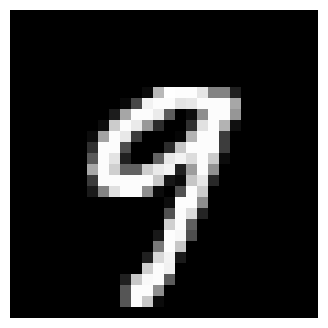

In [35]:
plt.rcParams['figure.figsize']=(4,4)
plt.imshow(image,cmap='gray')
plt.axis('off')
plt.show()

In [38]:
# 칼라사진 -> 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)
# %pip install opencv-python==4.8.1.78

In [40]:
import cv2
# 사진이미지를 흑백포맷으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg',cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

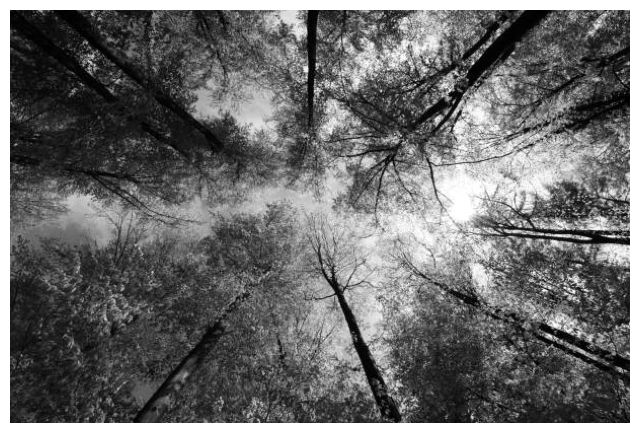

In [44]:
plt.figure(figsize=(8,10))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

## 1. 데이터 생성 및 전처리

In [47]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [49]:
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949],
       dtype=int64))

In [51]:
value, counts = np.unique(y_train,return_counts=True)
ratios=counts/y_train.shape[0]
dict(zip(value,ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [52]:
value, counts = np.unique(y_test,return_counts=True)
ratios=counts/y_test.shape[0]
dict(zip(value,ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2


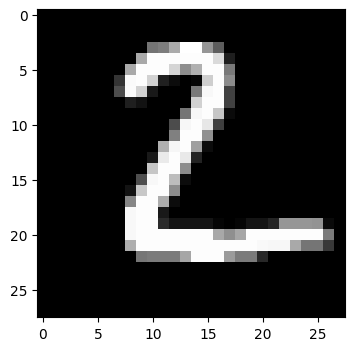

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [63]:
print(y_test[1])
plt.imshow(X_test[1],cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}",end="")
    print()

## 2. 모델 구성

In [61]:
#Train 6만개 => Train(5만개)+Val(1만개)로분리
(X_train,y_train),(X_test,y_test) = mnist.load_data() #6만개, 1만개로 분리되어 load 
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train=X_train[:50000]
y_train=y_train[:50000]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((50000, 28, 28),
 (50000,),
 (10000, 28, 28),
 (10000,),
 (10000, 28, 28),
 (10000,))

In [62]:
print('학습셋:',X_train.shape,y_train.shape )
print('검증셋:',X_val.shape,y_val.shape )
print('시험셋:',X_test.shape, y_test.shape )

학습셋: (50000, 28, 28) (50000,)
검증셋: (10000, 28, 28) (10000,)
시험셋: (10000, 28, 28) (10000,)


In [93]:
# 입력(독립) 변수(n,28,28) -> (n, 28*28) -> 실수로 형변환 -> 스케일조정 (/255.0)
train_X=X_train.reshape(50000,28*28).astype('float32')/255.0
val_X=X_val.reshape(10000,-1).astype('float32')/255.0
test_X=X_test.reshape(10000,784).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [91]:
# 종속(타겟)변수 : 분류분석을 위한 원핫 인코딩(to_categorical()이용, pd.getdummies)
train_Y= to_categorical(y_train)
val_Y= to_categorical(y_val)
test_Y= to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [94]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적: 수업시간중 fit 시간 절약)
train_idx = np.random.choice(50000,700)
val_idx   = np.random.choice(10000,300)
train_X=train_X[train_idx]
train_Y=train_Y[train_idx]
val_X=val_X[val_idx]
val_Y=val_Y[val_idx]


In [95]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

## 3. 학습과정 설정

In [97]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units= 2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%aks xhdrhk
model.add(Dense(units= 10, activation='softmax'))
model.summary()
# 타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_3 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


## 4. 모델학습

In [98]:
%%time
hist=model.fit(train_X, train_Y,
              validation_data=(val_X,val_Y), # 검증셋
              batch_size=350,
              epochs=200)

Epoch 1/200
2/2 [==============================] - 1s 283ms/step - loss: 2.3301 - accuracy: 0.0986 - val_loss: 2.3237 - val_accuracy: 0.1000
Epoch 2/200
2/2 [==============================] - 0s 32ms/step - loss: 2.3002 - accuracy: 0.1229 - val_loss: 2.3031 - val_accuracy: 0.1100
Epoch 3/200
2/2 [==============================] - 0s 30ms/step - loss: 2.2788 - accuracy: 0.1500 - val_loss: 2.2888 - val_accuracy: 0.1500
Epoch 4/200
2/2 [==============================] - 0s 35ms/step - loss: 2.2635 - accuracy: 0.1857 - val_loss: 2.2771 - val_accuracy: 0.1800
Epoch 5/200
2/2 [==============================] - 0s 31ms/step - loss: 2.2516 - accuracy: 0.2157 - val_loss: 2.2671 - val_accuracy: 0.1933
Epoch 6/200
2/2 [==============================] - 0s 28ms/step - loss: 2.2401 - accuracy: 0.2229 - val_loss: 2.2572 - val_accuracy: 0.2033
Epoch 7/200
2/2 [==============================] - 0s 37ms/step - loss: 2.2290 - accuracy: 0.2386 - val_loss: 2.2476 - val_accuracy: 0.2033
Epoch 8/200
2/2 [==

2/2 [==============================] - 0s 35ms/step - loss: 1.7146 - accuracy: 0.3329 - val_loss: 1.8710 - val_accuracy: 0.2900
Epoch 118/200
2/2 [==============================] - 0s 28ms/step - loss: 1.7122 - accuracy: 0.3329 - val_loss: 1.8688 - val_accuracy: 0.2900
Epoch 119/200
2/2 [==============================] - 0s 30ms/step - loss: 1.7097 - accuracy: 0.3329 - val_loss: 1.8671 - val_accuracy: 0.2900
Epoch 120/200
2/2 [==============================] - 0s 29ms/step - loss: 1.7073 - accuracy: 0.3329 - val_loss: 1.8660 - val_accuracy: 0.2900
Epoch 121/200
2/2 [==============================] - 0s 42ms/step - loss: 1.7047 - accuracy: 0.3329 - val_loss: 1.8645 - val_accuracy: 0.2900
Epoch 122/200
2/2 [==============================] - 0s 50ms/step - loss: 1.7023 - accuracy: 0.3329 - val_loss: 1.8626 - val_accuracy: 0.2900
Epoch 123/200
2/2 [==============================] - 0s 41ms/step - loss: 1.6998 - accuracy: 0.3329 - val_loss: 1.8606 - val_accuracy: 0.2900
Epoch 124/200
2/2 [=

Epoch 175/200
2/2 [==============================] - 0s 34ms/step - loss: 1.5885 - accuracy: 0.3943 - val_loss: 1.7955 - val_accuracy: 0.3233
Epoch 176/200
2/2 [==============================] - 0s 42ms/step - loss: 1.5867 - accuracy: 0.3957 - val_loss: 1.7948 - val_accuracy: 0.3233
Epoch 177/200
2/2 [==============================] - 0s 42ms/step - loss: 1.5848 - accuracy: 0.3929 - val_loss: 1.7946 - val_accuracy: 0.3233
Epoch 178/200
2/2 [==============================] - 0s 37ms/step - loss: 1.5830 - accuracy: 0.3943 - val_loss: 1.7939 - val_accuracy: 0.3267
Epoch 179/200
2/2 [==============================] - 0s 36ms/step - loss: 1.5812 - accuracy: 0.3943 - val_loss: 1.7925 - val_accuracy: 0.3267
Epoch 180/200
2/2 [==============================] - 0s 31ms/step - loss: 1.5794 - accuracy: 0.3943 - val_loss: 1.7914 - val_accuracy: 0.3300
Epoch 181/200
2/2 [==============================] - 0s 31ms/step - loss: 1.5776 - accuracy: 0.3943 - val_loss: 1.7904 - val_accuracy: 0.3300
Epoch 

## 5. 모델 평가하기

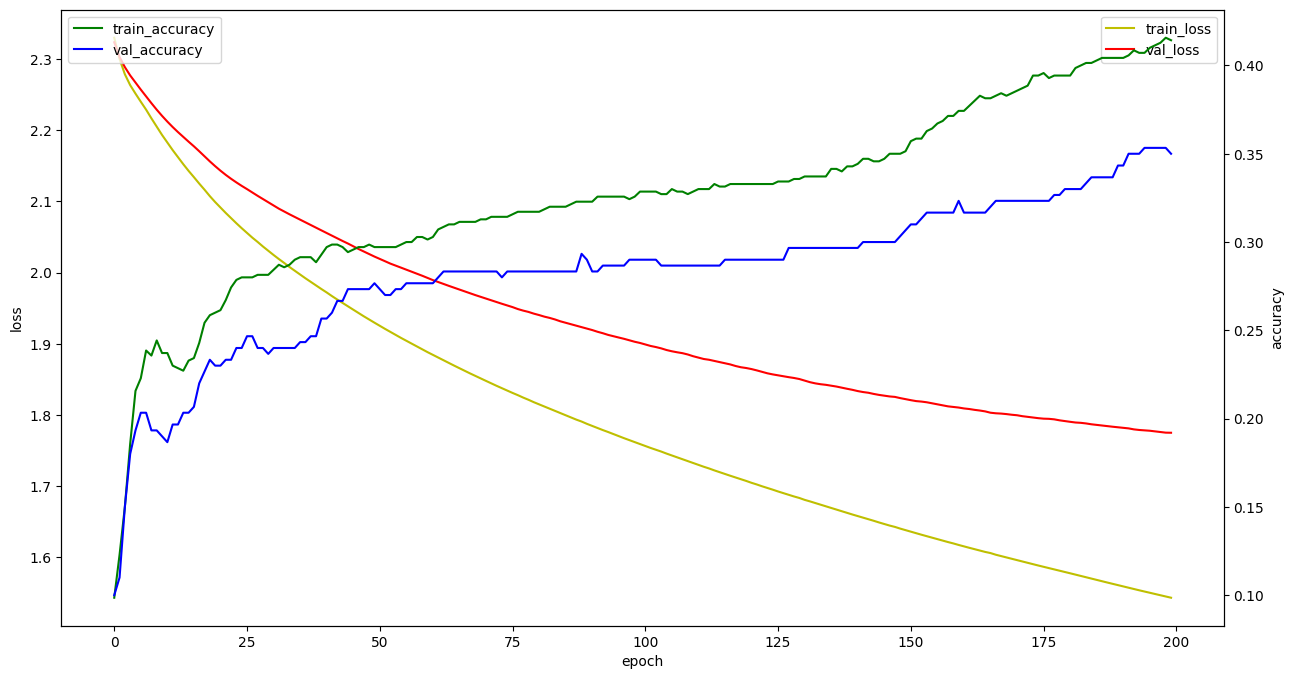

In [102]:
# 학습과정살펴보기 (시각화)
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()

In [103]:
# 모델평가(시험셋=test셋)
loss_metrics=model.evaluate(test_X, test_Y,batch_size=100, verbose=0)
print('loss:', loss_metrics[0])
print('accuracy:', loss_metrics[1])

loss: 1.7547491788864136
accuracy: 0.36239999532699585


## 위모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어추가, units수 증가)
- 과적합 방지(validation data추가, 활성화함수를 relu계열, tanh,, Dropdout추가, 배치정규화, L2정규화(규제)...)
- epoch 조정
- optimizer 변경


In [139]:
%%time
(X_train,y_train),(X_test,y_test) = mnist.load_data() #6만개, 1만개로 분리되어 load 
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train=X_train[:50000]
y_train=y_train[:50000]

# 입력(독립) 변수(n,28,28) -> (n, 28*28) -> 실수로 형변환 -> 스케일조정 (/255.0)
train_X=X_train.reshape(50000,28*28).astype('float32')/255.0
val_X=X_val.reshape(10000,-1).astype('float32')/255.0
test_X=X_test.reshape(10000,784).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

# 종속(타겟)변수 : 분류분석을 위한 원핫 인코딩(to_categorical()이용, pd.getdummies)
train_Y= to_categorical(y_train)
val_Y= to_categorical(y_val)
test_Y= to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적: 수업시간중 fit 시간 절약)
# train_idx = np.random.choice(50000,700)
# val_idx   = np.random.choice(10000,300)
# train_X=train_X[train_idx]
# train_Y=train_Y[train_idx]
# val_X=val_X[val_idx]
# val_Y=val_Y[val_idx]
print(train_X.shape, val_X.shape, test_X.shape,train_Y.shape, val_Y.shape, test_Y.shape)
#모델생성(784->1024->512->128->10) 및 학습과정 설정
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units= 1024))  #1024개 출력층을 배치 정규화
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.2))

model.add(Dense(units= 512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units= 128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units= 10, activation='softmax'))
model.summary()
# 타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             optimizer='Nadam',
             metrics=['accuracy'])
#모델학습
hist=model.fit(train_X, train_Y,
              validation_data=(val_X,val_Y), # 검증셋
              batch_size=1000, # 크면 학습속도가 빨라지지만 메모리 부족이 뜰 수 도 있음
              epochs=30)  # 

(50000, 784) (10000, 784) (10000, 784) (50000, 10) (10000, 10) (10000, 10)
Model: "sequential_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_67 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization_15 (Bat  (None, 1024)             4096      
 chNormalization)                                                
                                                                 
 leaky_re_lu_21 (LeakyReLU)  (None, 1024)              0         
                                                                 
 dropout_4 (Dropout)         (None, 1024)              0         
                                                                 
 dense_68 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_16 (Bat  (None, 512)   

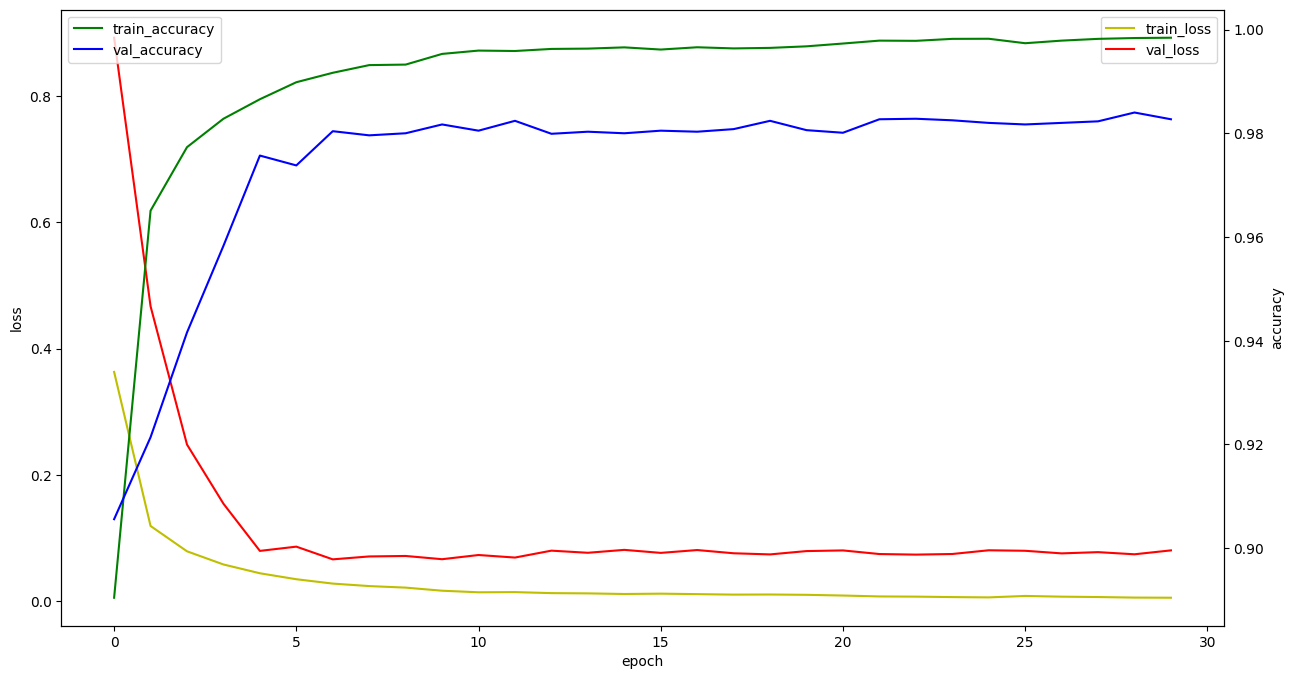

loss: 0.0712706446647644
accuracy: 0.9843999743461609


In [140]:
# 학습과정살펴보기 (시각화)
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()
# 모델평가(시험셋=test셋)
loss_metrics=model.evaluate(test_X, test_Y,batch_size=100, verbose=0)
print('loss:', loss_metrics[0])
print('accuracy:', loss_metrics[1])

In [145]:
# 교차표
y_test #실제값
#또는
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1)==y_test)


True

In [149]:
y_hat = model.predict(test_X).argmax(axis=1) # 예측값
y_hat = np.argmax(model.predict(test_X),axis=1)

313/313 [==============================] - 4s 11ms/step


In [150]:
pd.crosstab(y_test,y_hat,rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,972,1,0,0,0,1,3,1,1,1
1,0,1126,2,1,0,1,2,1,2,0
2,4,1,1015,1,2,0,2,4,3,0
3,0,0,3,992,1,5,0,4,4,1
4,0,0,3,0,963,0,3,1,0,12
5,3,0,0,7,1,872,6,1,1,1
6,2,2,0,0,1,1,950,0,2,0
7,1,1,7,1,1,0,0,1015,1,1
8,6,0,2,3,2,4,0,4,949,4


In [151]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_hat)

array([[ 972,    1,    0,    0,    0,    1,    3,    1,    1,    1],
       [   0, 1126,    2,    1,    0,    1,    2,    1,    2,    0],
       [   4,    1, 1015,    1,    2,    0,    2,    4,    3,    0],
       [   0,    0,    3,  992,    1,    5,    0,    4,    4,    1],
       [   0,    0,    3,    0,  963,    0,    3,    1,    0,   12],
       [   3,    0,    0,    7,    1,  872,    6,    1,    1,    1],
       [   2,    2,    0,    0,    1,    1,  950,    0,    2,    0],
       [   1,    1,    7,    1,    1,    0,    0, 1015,    1,    1],
       [   6,    0,    2,    3,    2,    4,    0,    4,  949,    4],
       [   2,    2,    0,    2,    5,    0,    0,    5,    3,  990]],
      dtype=int64)

In [153]:
# 틀린갯수
accuracy =loss_metrics[1]
10000-10000*accuracy

156.0002565383911

# 콜백함수 1 : 로그출력

In [4]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint # fit 할때 기본적으로 씀
from tensorflow.keras.callbacks import ReduceLROnPlateau #과적합이 심할때 씀

In [22]:
%%time
# 특정 에포크마다 로그출력하도록 제한하는 callback 클래스
class CustomHistory(Callback):
    def __init__(self): #생성자함수
        self.epoch=0
    def on_epoch_end(self, batch, logs={}):
        ' 1 epoch 수행 후 자동 실행되는 함수'
        self.epoch += 1
        if self.epoch%10==0: # 10 epoch마다 로그출력
            print('epoch:{},loss:{:.4f}, acc:{:.4f}, val_loss:{:.4f}, val_acc{:.4f}'.format(
                            self.epoch, 
                          logs.get('loss','-'), 
                          logs.get('accuracy','-'), 
                          logs.get('val_loss','-'), 
                          logs.get('val_accuracy','-')
            ))
 
(X_train,y_train),(X_test,y_test) = mnist.load_data() #6만개, 1만개로 분리되어 load 
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train=X_train[:50000]
y_train=y_train[:50000]

# 입력(독립) 변수(n,28,28) -> (n, 28*28) -> 실수로 형변환 -> 스케일조정 (/255.0)
train_X=X_train.reshape(50000,28*28).astype('float32')/255.0
val_X=X_val.reshape(10000,-1).astype('float32')/255.0
test_X=X_test.reshape(10000,784).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

# 종속(타겟)변수 : 분류분석을 위한 원핫 인코딩(to_categorical()이용, pd.getdummies)
train_Y= to_categorical(y_train)
val_Y= to_categorical(y_val)
test_Y= to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적: 수업시간중 fit 시간 절약)
train_idx = np.random.choice(50000,700)
val_idx   = np.random.choice(10000,300)
train_X=train_X[train_idx]
train_Y=train_Y[train_idx]
val_X=val_X[val_idx]
val_Y=val_Y[val_idx]
print(train_X.shape, val_X.shape, test_X.shape,train_Y.shape, val_Y.shape, test_Y.shape)

# 모델생성(784->2->10) 및 학습과정 설정
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units= 2))
model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units= 10, activation='softmax'))
model.summary()

# 타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

#모델학습
customHistory =CustomHistory()
print(customHistory.epoch) # 처음엔 0
hist=model.fit(train_X, train_Y,
              validation_data=(val_X,val_Y), # 검증셋
              batch_size=1000, # 크면 학습속도가 빨라지지만 메모리 부족이 뜰 수 도 있음
              epochs=30,
              verbose=0,
              callbacks=[customHistory]
              )  

(700, 784) (300, 784) (10000, 784) (700, 10) (300, 10) (10000, 10)
Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_8 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_17 (Dense)            (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________
0
epoch:10,loss:2.2322, acc:0.1600, val_loss:2.2216, val_acc0.2000
epoch:20,loss:2.1739, acc:0.1886, val_loss:2.1637, val_acc0.2233
epoch:30,loss:2.1272, acc:0.1943, val_loss:2.1171, val_acc0.2300
CPU times: total: 2.16 s
Wall time: 2.01 s


 # ※ 콜백함수2: EarlyStopping
 - val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
 - val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [24]:
%%time
# 모델생성(784->2->10) 및 학습과정 설정
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units= 2))
model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units= 10, activation='softmax'))
model.summary()

# 타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

#모델학습
earlyStopping=EarlyStopping(monitor='val_accuracy',
                           patience=3)    

hist=model.fit(train_X, train_Y,
              validation_data=(val_X,val_Y), # 검증셋
              batch_size=1000, # 크면 학습속도가 빨라지지만 메모리 부족이 뜰 수 도 있음
              epochs=30,
              verbose=2,
              callbacks=[earlyStopping]
              )  

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_10 (LeakyReLU)  (None, 2)                 0         
                                                                 
 dense_21 (Dense)            (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
1/1 - 1s - loss: 2.2989 - accuracy: 0.1043 - val_loss: 2.3034 - val_accuracy: 0.1400 - 579ms/epoch - 579ms/step
Epoch 2/30
1/1 - 0s - loss: 2.2933 - accuracy: 0.1043 - val_loss: 2.2997 - val_accuracy: 0.1367 - 49ms/epoch - 49ms/step
Epoch 3/30
1/1 - 0s - loss: 2.2885 - accuracy: 0.1229 - val_loss: 2.296

# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_acc(val_loss, loss, acc)값이 좋을 때마다 모델을 자동 저장하는 콜백
  모델 파일명 : ex) mnist_102번째_accuracy:0.641.h5 d

In [25]:
%%time
# 모델생성(784->2->10) 및 학습과정 설정
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units= 2))
model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units= 10, activation='softmax'))
model.summary()

# 타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

#모델학습
earlyStopping=EarlyStopping(monitor='val_accuracy',
                           patience=30)    
#모델자동저장콜벡
import os
model_save_folder='model07/'
if not os.path.exists(model_save_folder): #폴더가 없으면
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist_{epoch:03d}_val{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy', #모니터할 지표(기본값은 val_loss)
                            save_best_only=True, #모니터링 지표가 개선된 경우만 저장
                            mode = 'max', #값이 커질수록 저장
                            verbose=1
                            )   
    

hist=model.fit(train_X, train_Y,
              validation_data=(val_X,val_Y), # 검증셋
              batch_size=1000, # 크면 학습속도가 빨라지지만 메모리 부족이 뜰 수 도 있음
              epochs=30,
              verbose=2,
              callbacks=[earlyStopping, checkpoint]
              )  

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_11 (LeakyReLU)  (None, 2)                 0         
                                                                 
 dense_23 (Dense)            (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.06333, saving model to model07\mnist_001_val0.0633.h5
1/1 - 1s - loss: 2.3125 - accuracy: 0.0529 - val_loss: 2.3086 - val_accuracy: 0.0633 - 1s/epoch - 1s/step
Epoch 2/30

Epoch 2: val_accuracy did not improve from 0.06333
1/1 - 0s - loss: 2.3055 - accuracy

In [27]:
# 최종 학습 모델
model.evaluate(test_X,test_Y)

313/313 [==============================] - 1s 2ms/step - loss: 2.0965 - accuracy: 0.2155


[2.0964672565460205, 0.21549999713897705]

In [28]:
# 저장된 모델 중 최선의 모델
model2=load_model('model07/mnist_022_val0.2300.h5')
model2.evaluate(test_X,test_Y)

313/313 [==============================] - 1s 2ms/step - loss: 2.1768 - accuracy: 0.2139


[2.1768012046813965, 0.21389999985694885]

# ※ 콜백함수 4: ReduceLROnPlateau
- 성능이 정체될 때 학습률(learing_rate)을 낮춰서 더 세밀하게 최적점을 찾도록 도와주는 콜백
- 평소에 즐겨 사용하지 않으나 출력시 과적합 확인 될 때 사용함

In [30]:
%%time
# 모델생성(784->2->10) 및 학습과정 설정
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units= 2))
model.add(LeakyReLU(alpha=0.01))
model.add(Dense(units= 10, activation='softmax'))
model.summary()

# 타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
             # optimizer=Adam(learning_rate=0.001)
             optimizer='adam',
             metrics=['accuracy'])

#모델학습
earlyStopping=EarlyStopping(monitor='val_accuracy',
                           patience=30)    
#성능 정체시 학습률 낮추는 콜백
reduce_lr=ReduceLROnPlateau(monitor='val_accuracy',
                           patience=2,
                           factor=0.5,
                           min_lr=1e-6     #학습률 learning rate가 0이되면 학습에 의미가 없어짐
                           )

hist=model.fit(train_X, train_Y,
              validation_data=(val_X,val_Y), # 검증셋
              batch_size=1000, # 크면 학습속도가 빨라지지만 메모리 부족이 뜰 수 도 있음
              epochs=30,
              verbose=2,
              callbacks=[earlyStopping, reduce_lr]
              )  

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_26 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_13 (LeakyReLU)  (None, 2)                 0         
                                                                 
 dense_27 (Dense)            (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
1/1 - 0s - loss: 2.3336 - accuracy: 0.1129 - val_loss: 2.3278 - val_accuracy: 0.1100 - lr: 0.0010 - 469ms/epoch - 469ms/step
Epoch 2/30
1/1 - 0s - loss: 2.3246 - accuracy: 0.1129 - val_loss: 2.3198 - val_accuracy: 0.1233 - lr: 0.0010 - 37ms/epoch - 37ms/step
Epoch 3/30
1/1 - 0s - loss: 2.3173 - accuracy